# GRPO Baseline: Action-Only (Stage 2)

GRPO поверх SFT checkpoint. Модель напрямую выдаёт действие `0/1/2`.

- **Init:** веса из SFT (`gleror/sft-baseline-res`)
- **Train env:** `MiniGrid-Empty-16x16-v0`
- **Eval:** 6x6 и 16x16, сравнение с SFT

In [1]:
!pip install -q gymnasium minigrid torch torchvision pillow tqdm matplotlib transformers huggingface-hub safetensors
!test -d nanoVLM || git clone --branch v0.1 --depth 1 https://github.com/huggingface/nanoVLM.git

import sys
sys.path.insert(0, "nanoVLM")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 3.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 101.8 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0

In [2]:
import copy
import json
import random
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import minigrid  # noqa: F401
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torch.distributions import Categorical
from tqdm.auto import tqdm

from data.processors import get_image_processor, get_tokenizer
from models.config import VLMConfig
from models.vision_language_model import VisionLanguageModel

SFT_DATASET_CANDIDATES = [
    Path("/kaggle/input/datasets/gleror/sft-curriculum-res"),
    Path("output"),
]
SFT_DATASET_PATH = next((p for p in SFT_DATASET_CANDIDATES if (p / "checkpoint").exists()), None)

SFT_CHECKPOINT = SFT_DATASET_PATH / "checkpoint"
OUTPUT_DIR = Path("/kaggle/working/grpo_baseline" if Path("/kaggle").exists() else "grpo_output")

# TRAIN_ENV = "MiniGrid-Empty-16x16-v0"
TRAIN_ENV = "MiniGrid-Empty-6x6-v0"
EVAL_ENVS = ["MiniGrid-Empty-6x6-v0", "MiniGrid-Empty-16x16-v0"]
PROMPT = (
    "Question: You are a navigation agent in a grid world. "
    "Choose the next action: 0=left, 1=right, 2=forward. Answer:"
)

K_GROUP = 8
N_ITERATIONS = 60
MAX_STEPS = 50
EVAL_MAX_STEPS = 100
LR = 1e-5
BETA_KL = 0.01
STEP_PENALTY = 0.01
DISTANCE_REWARD_SCALE = 0.5
PER_STEP_PROGRESS_SCALE = 0.1
TEMPERATURE = 1.5
EVAL_EVERY = 20
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = get_tokenizer(VLMConfig.lm_tokenizer)
image_processor = get_image_processor(VLMConfig.vit_img_size)
ACTION_TOKEN_IDS = [tokenizer.encode(str(a), add_special_tokens=False)[0] for a in range(3)]

print(f"Device: {device}")
print(f"SFT checkpoint: {SFT_CHECKPOINT}")
print(f"Action token IDs: {ACTION_TOKEN_IDS}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/489 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device: cuda
SFT checkpoint: /kaggle/input/datasets/gleror/sft-curriculum-res/checkpoint
Action token IDs: [32, 33, 34]


## 2. Load SFT checkpoint

`model` — обучаемая политика. `ref_model` — замороженная SFT-копия на CPU для KL penalty.

In [3]:
model = VisionLanguageModel.from_pretrained(str(SFT_CHECKPOINT)).to(device)
model.train()

ref_model = VisionLanguageModel.from_pretrained(str(SFT_CHECKPOINT)).to("cpu")
ref_model.eval()
for p in ref_model.parameters():
    p.requires_grad = False

with open(SFT_DATASET_PATH / "results.json") as f:
    sft_results = json.load(f)
print("SFT eval results:")
for env_id, metrics in sft_results.get("eval", {}).items():
    print(f"  {env_id}: success={metrics['success_rate']:.1%}")

Loading SFT checkpoint...
SFT eval results:
  MiniGrid-Empty-6x6-v0: success=100.0%
  MiniGrid-Empty-8x8-v0: success=100.0%
  MiniGrid-Empty-16x16-v0: success=0.0%


In [11]:
model = VisionLanguageModel.from_pretrained(str(SFT_CHECKPOINT)).to(device)
model.eval()

EVAL_ENVS = [
    # "MiniGrid-Empty-6x6-v0",
    "MiniGrid-Empty-8x8-v0",
    # "MiniGrid-Empty-16x16-v0",
]
MAX_STEPS = 100
SEED = 42

print("Evaluation on 8*8")
eval_results = {}
for env_id in EVAL_ENVS:
    result = evaluate_policy(model, env_id, n_episodes=50, max_steps=MAX_STEPS, seed=SEED)
    eval_results[env_id] = result
    print(f"  {env_id}: success={result['success_rate']:.1%}, "
          f"return={result['avg_return']:.3f}, len={result['avg_length']:.1f}")

Evaluation on 8*8


Evaluating: 100%|██████████| 50/50 [09:31<00:00, 11.44s/ep, succ=2/50, avg_ret=0.03, avg_len=98.5]

  MiniGrid-Empty-8x8-v0: success=4.0%, return=0.031, len=98.5


## 3. Policy helpers

In [5]:
def get_action_logits(model, input_ids, image, attention_mask=None):
    """Logits всего vocab на последней позиции промпта."""
    image_embd = model.vision_encoder(image)
    image_embd = model.MP(image_embd)
    token_embd = model.decoder.token_embedding(input_ids)
    combined_embd = torch.cat((image_embd, token_embd), dim=1)

    if attention_mask is not None:
        img_mask = torch.ones(
            image_embd.size(0), image_embd.size(1),
            device=attention_mask.device, dtype=attention_mask.dtype,
        )
        attention_mask = torch.cat((img_mask, attention_mask), dim=1)

    hidden = model.decoder(combined_embd, attention_mask)
    logits = model.decoder.head(hidden)
    logits = logits[:, image_embd.size(1):, :]
    return logits[:, -1, :]


def action_log_probs_and_kl(model, ref_model, input_ids, image, attention_mask, action):
    """log pi(a|s) и KL(pi || pi_ref) только по токенам действий."""
    logits = get_action_logits(model, input_ids, image, attention_mask)
    action_logits = logits[:, ACTION_TOKEN_IDS]
    log_probs = F.log_softmax(action_logits, dim=-1)
    action_idx = torch.tensor([action], device=logits.device)
    log_prob = log_probs[0, action_idx]

    with torch.no_grad():
        ref_logits = get_action_logits(
            ref_model,
            input_ids.cpu(), image.cpu(), attention_mask.cpu() if attention_mask is not None else None,
        )
        ref_action_logits = ref_logits[:, ACTION_TOKEN_IDS].to(logits.device)

    p = F.softmax(action_logits, dim=-1)
    q = F.softmax(ref_action_logits, dim=-1)
    kl = (p * (p.log() - q.log())).sum(dim=-1).mean()
    return log_prob, kl


def parse_action(text):
    text = text.strip()
    for ch in text:
        if ch in "012":
            return int(ch)
    return 2


@torch.no_grad()
def predict_action_greedy(model, env):
    """Greedy action для eval (без сэмплирования)."""
    model.eval()
    rgb = env.render()
    image = Image.fromarray(rgb).convert("RGB")
    processed = image_processor(image).unsqueeze(0).to(device)
    input_ids = tokenizer.encode(PROMPT, return_tensors="pt").to(device)
    attention_mask = torch.ones_like(input_ids)
    logits = get_action_logits(model, input_ids, processed, attention_mask)
    action_logits = logits[:, ACTION_TOKEN_IDS]
    action = action_logits.argmax(dim=-1).item()
    model.train()
    return action


def evaluate_policy(model, env_id, n_episodes=30, max_steps=200, seed=0):
    env = gym.make(env_id, render_mode="rgb_array")
    successes, returns, lengths = 0, [], []
    model.eval()
    
    pbar = tqdm(total=n_episodes, desc="Evaluating", unit="ep")
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        total_reward = 0.0
        for step in range(max_steps):
            action = predict_action_greedy(model, env)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            if terminated or truncated:
                if terminated and reward > 0:
                    successes += 1
                lengths.append(step + 1)
                break
        else:
            lengths.append(max_steps)
        returns.append(total_reward)
        
        pbar.set_postfix({
            "succ": f"{successes}/{ep+1}",
            "return": f"{np.mean(returns):.2f}",
            "len": f"{np.mean(lengths):.1f}"
        })
        pbar.update(1)
    
    pbar.close()
    env.close()
    model.train()
    return {
        "success_rate": successes / n_episodes,
        "avg_return": float(np.mean(returns)),
        "avg_length": float(np.mean(lengths)),
    }

## 4. Rollout + GRPO update

Для одного `seed` делаем K эпизодов (одинаковый старт). Reward нормализуем внутри группы (z-score).

In [6]:
def find_goal(env):
    for x in range(env.width):
        for y in range(env.height):
            cell = env.grid.get(x, y)
            if cell is not None and cell.type == "goal":
                return (x, y)
    raise RuntimeError("Goal not found")


def manhattan_dist(pos, goal):
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])


def compute_advantages(rewards):
    """Z-score; если std≈0 — rank-based, чтобы advantages не были все нули."""
    rewards = np.asarray(rewards, dtype=np.float32)
    std = rewards.std()
    if std > 1e-4:
        return (rewards - rewards.mean()) / (std + 1e-8)
    ranks = np.argsort(np.argsort(rewards)).astype(np.float32)
    return (ranks - ranks.mean()) / (ranks.std() + 1e-8)


@torch.no_grad()
def rollout_episode(env_id, max_steps, seed):
    """On-policy rollout с temperature для разнообразия при одном seed."""
    env = gym.make(env_id, render_mode="rgb_array")
    obs, _ = env.reset(seed=seed)
    unwrapped = env.unwrapped
    goal_pos = find_goal(unwrapped)
    initial_dist = manhattan_dist(unwrapped.agent_pos, goal_pos)

    steps = []
    success = False
    episode_reward = 0.0
    prev_dist = initial_dist

    for _ in range(max_steps):
        rgb = env.render()
        image = Image.fromarray(rgb).convert("RGB")
        processed = image_processor(image).unsqueeze(0).to(device)
        input_ids = tokenizer.encode(PROMPT, return_tensors="pt").to(device)
        attention_mask = torch.ones_like(input_ids)

        logits = get_action_logits(model, input_ids, processed, attention_mask)
        action_logits = logits[:, ACTION_TOKEN_IDS] / TEMPERATURE
        dist = Categorical(logits=action_logits)
        action = dist.sample().item()

        obs, reward, terminated, truncated, _ = env.step(action)

        new_dist = manhattan_dist(unwrapped.agent_pos, goal_pos)
        episode_reward += PER_STEP_PROGRESS_SCALE * (prev_dist - new_dist)
        prev_dist = new_dist

        steps.append({
            "input_ids": input_ids.detach().cpu(),
            "attention_mask": attention_mask.detach().cpu(),
            "image": processed.detach().cpu(),
            "action": action,
        })
        if terminated or truncated:
            success = terminated and reward > 0
            break

    final_dist = manhattan_dist(unwrapped.agent_pos, goal_pos)
    progress = (initial_dist - final_dist) / max(initial_dist, 1)
    episode_reward += (1.0 if success else 0.0) + DISTANCE_REWARD_SCALE * progress
    episode_reward -= STEP_PENALTY * len(steps)

    env.close()
    return {
        "steps": steps,
        "episode_reward": episode_reward,
        "success": success,
        "length": len(steps),
    }


def grpo_step(optimizer, rollout_seed, train_env, max_steps, debug=False):
    """GRPO: K rollouts на одном seed, подсчет advantages и backward после каждого шага."""
    rollouts = [rollout_episode(train_env, max_steps, rollout_seed) for _ in range(K_GROUP)]
    rewards = np.array([r["episode_reward"] for r in rollouts], dtype=np.float32)
    advantages = compute_advantages(rewards)

    if debug:
        print(f"  rewards: {rewards.round(3)}")
        print(f"  advantages: {advantages.round(3)}")
        print(f"  successes: {[r['success'] for r in rollouts]}")

    optimizer.zero_grad(set_to_none=True)
    total_loss = 0.0
    n_terms = 0

    for rollout, adv in zip(rollouts, advantages):
        adv_val = float(adv)
        n_steps = len(rollout["steps"])
        if n_steps == 0:
            continue

        for step in rollout["steps"]:
            input_ids = step["input_ids"].to(device)
            attention_mask = step["attention_mask"].to(device)
            image = step["image"].to(device)
            action = step["action"]
            log_prob, kl = action_log_probs_and_kl(
                model, ref_model, input_ids, image, attention_mask, action
            )
            # backward по шагу — пик VRAM = 1 forward, не весь rollout
            step_loss = (-adv_val * log_prob + BETA_KL * kl) / (n_steps * K_GROUP)
            step_loss.backward()
            total_loss += step_loss.item()
            n_terms += 1

    if n_terms == 0:
        return {
            "loss": 0.0,
            "mean_reward": float(rewards.mean()),
            "success_rate": float(np.mean([r["success"] for r in rollouts])),
            "mean_length": float(np.mean([r["length"] for r in rollouts])),
        }

    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    return {
        "loss": total_loss,
        "mean_reward": float(rewards.mean()),
        "success_rate": float(np.mean([r["success"] for r in rollouts])),
        "mean_length": float(np.mean([r["length"] for r in rollouts])),
    }

## 5. GRPO Training Loop

In [7]:
# K_GROUP = 8
# N_ITERATIONS = 60
# MAX_STEPS = 50 
# EVAL_MAX_STEPS = 100 
# LR = 1e-5
# BETA_KL = 0.01
# STEP_PENALTY = 0.01
# DISTANCE_REWARD_SCALE = 0.5
# PER_STEP_PROGRESS_SCALE = 0.1
# TEMPERATURE = 1.5 
# EVAL_EVERY = 20
# SEED = 42
TRAIN_ENV = "MiniGrid-Empty-8x8-v0"
EVAL_ENVS = ["MiniGrid-Empty-8x8-v0", "MiniGrid-Empty-16x16-v0"]
K_GROUP = 8
N_ITERATIONS = 20
MAX_STEPS = 50 
EVAL_MAX_STEPS = 100
LR = 1e-5
BETA_KL = 0.01
STEP_PENALTY = 0.005
DISTANCE_REWARD_SCALE = 0.5
PER_STEP_PROGRESS_SCALE = 0.1
TEMPERATURE = 1.5
EVAL_EVERY = 5
SEED = 42

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

train_history = {
    "iteration": [],
    "loss": [],
    "mean_reward": [],
    "rollout_success": [],
    "mean_length": [],
}
eval_history = {env_id: {"iteration": [], "success_rate": [], "avg_return": []} for env_id in EVAL_ENVS}

pbar = tqdm(range(1, N_ITERATIONS + 1), desc="GRPO")
for it in pbar:
    rollout_seed = SEED + it * 1000 + random.randint(0, 999)
    stats = grpo_step(optimizer, rollout_seed, TRAIN_ENV, MAX_STEPS, debug=(it == 1))

    if device.type == "cuda":
        torch.cuda.empty_cache()

    train_history["iteration"].append(it)
    for key in ("loss", "mean_reward", "success_rate", "mean_length"):
        mapped = "rollout_success" if key == "success_rate" else key
        train_history[mapped].append(stats[key])

    pbar.set_postfix(
        loss=f"{stats['loss']:.3f}",
        rew=f"{stats['mean_reward']:.2f}",
        succ=f"{stats['success_rate']:.0%}",
    )

    if it % EVAL_EVERY == 0 or it == N_ITERATIONS:
        for env_id in EVAL_ENVS:
            eval_steps = EVAL_MAX_STEPS if "16x16" in env_id else MAX_STEPS
            metrics = evaluate_policy(model, env_id, n_episodes=20, max_steps=eval_steps, seed=SEED)
            eval_history[env_id]["iteration"].append(it)
            eval_history[env_id]["success_rate"].append(metrics["success_rate"])
            eval_history[env_id]["avg_return"].append(metrics["avg_return"])
        msg = " | ".join(
            f"{e.split('-')[2]}={eval_history[e]['success_rate'][-1]:.0%}"
            for e in EVAL_ENVS
        )
        print(f"\nIter {it} eval: {msg}")

GRPO:   0%|          | 0/20 [00:00<?, ?it/s]

  rewards: [2.44  2.445 2.44  2.43  2.445 2.445 2.445 2.445]
  advantages: [-0.378  0.63  -0.378 -2.394  0.63   0.63   0.63   0.63 ]
  successes: [True, True, True, True, True, True, True, True]


Evaluating: 100%|██████████| 20/20 [00:10<00:00,  1.82ep/s, succ=20/20, return=0.96, len=11.0]

GRPO:  25%|██▌       | 5/20 [06:52<25:19, 101.29s/it, loss=0.001, rew=2.44, succ=100%]


Iter 5 eval: 8x8=100% | 16x16=0%


Evaluating: 100%|██████████| 20/20 [00:10<00:00,  1.83ep/s, succ=20/20, return=0.96, len=11.0]

GRPO:  50%|█████     | 10/20 [13:09<15:48, 94.84s/it, loss=0.001, rew=2.44, succ=100%]


Iter 10 eval: 8x8=100% | 16x16=0%


Evaluating: 100%|██████████| 20/20 [00:11<00:00,  1.80ep/s, succ=20/20, return=0.96, len=11.0]

GRPO:  75%|███████▌  | 15/20 [19:33<07:59, 95.96s/it, loss=0.001, rew=2.44, succ=100%]


Iter 15 eval: 8x8=100% | 16x16=0%


Evaluating: 100%|██████████| 20/20 [00:11<00:00,  1.78ep/s, succ=20/20, return=0.96, len=11.0]

GRPO: 100%|██████████| 20/20 [26:05<00:00, 78.26s/it, loss=0.001, rew=2.44, succ=100%]


Iter 20 eval: 8x8=100% | 16x16=0%


## 6. Final Evaluation & Comparison with SFT

In [8]:
print("Final GRPO evaluation")
EVAL_MAX_STEPS = 200
grpo_eval = {}
for env_id in EVAL_ENVS:
    eval_steps = EVAL_MAX_STEPS if "16x16" in env_id else MAX_STEPS
    grpo_eval[env_id] = evaluate_policy(model, env_id, n_episodes=20, max_steps=eval_steps, seed=SEED)
    print(f"  {env_id}: success={grpo_eval[env_id]['success_rate']:.1%}, "
          f"return={grpo_eval[env_id]['avg_return']:.3f}")

sft_eval = sft_results.get("eval", {})

def env_label(env_id):
    return env_id.replace("MiniGrid-Empty-", "").replace("-v0", "")

print("\nСравнение: SFT vs GRPO")
print(f"{'Method':<8} {'Env':<8} {'Success':>10} {'Return':>10}")
print("-" * 40)
for env_id in EVAL_ENVS:
    label = env_label(env_id)
    sft_sr = sft_eval.get(env_id, {}).get("success_rate", 0.0)
    sft_ret = sft_eval.get(env_id, {}).get("avg_return", 0.0)
    grpo_sr = grpo_eval[env_id]["success_rate"]
    grpo_ret = grpo_eval[env_id]["avg_return"]
    print(f"{'SFT':<8} {label:<8} {sft_sr:>9.0%} {sft_ret:>10.3f}")
    print(f"{'GRPO':<8} {label:<8} {grpo_sr:>9.0%} {grpo_ret:>10.3f}")
    print()

Final GRPO evaluation...


Evaluating: 100%|██████████| 20/20 [00:10<00:00,  1.83ep/s, succ=20/20, return=0.96, len=11.0]


  MiniGrid-Empty-8x8-v0: success=100.0%, return=0.961


Evaluating: 100%|██████████| 20/20 [03:27<00:00, 10.38s/ep, succ=0/20, return=0.00, len=200.0]

  MiniGrid-Empty-16x16-v0: success=0.0%, return=0.000

=== Comparison: SFT vs GRPO ===
Method   Env         Success     Return
----------------------------------------
SFT      8x8           100%      0.957
GRPO     8x8           100%      0.961

SFT      16x16           0%      0.000
GRPO     16x16           0%      0.000



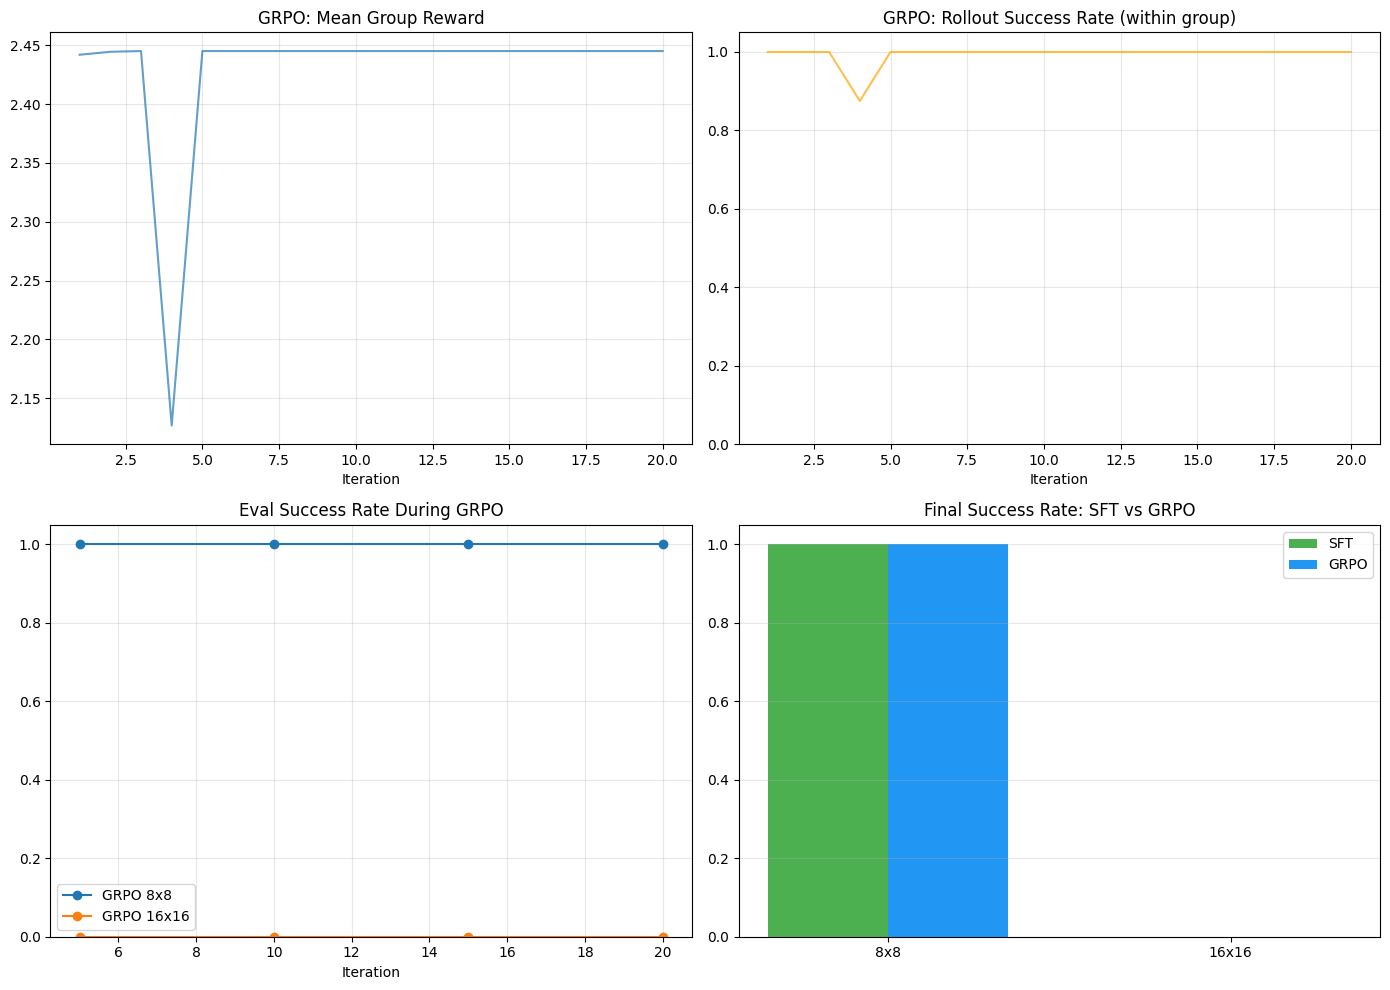

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(train_history["iteration"], train_history["mean_reward"], alpha=0.7)
axes[0, 0].set_title("GRPO: Mean Group Reward")
axes[0, 0].set_xlabel("Iteration")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(train_history["iteration"], train_history["rollout_success"], alpha=0.7, color="orange")
axes[0, 1].set_title("GRPO: Rollout Success Rate (within group)")
axes[0, 1].set_xlabel("Iteration")
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].grid(True, alpha=0.3)

for env_id in EVAL_ENVS:
    label = env_label(env_id)
    axes[1, 0].plot(
        eval_history[env_id]["iteration"],
        eval_history[env_id]["success_rate"],
        marker="o", label=f"GRPO {label}",
    )
axes[1, 0].set_title("Eval Success Rate During GRPO")
axes[1, 0].set_xlabel("Iteration")
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

x = np.arange(len(EVAL_ENVS))
width = 0.35
sft_rates = [sft_eval.get(e, {}).get("success_rate", 0.0) for e in EVAL_ENVS]
grpo_rates = [grpo_eval[e]["success_rate"] for e in EVAL_ENVS]
labels = [env_label(e) for e in EVAL_ENVS]
axes[1, 1].bar(x - width / 2, sft_rates, width, label="SFT", color="#4CAF50")
axes[1, 1].bar(x + width / 2, grpo_rates, width, label="GRPO", color="#2196F3")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(labels)
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].set_title("Final Success Rate: SFT vs GRPO")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_DIR / "grpo_learning_curves.png", dpi=150)
plt.show()

сохраним результаты

In [10]:
model.save_pretrained(str(OUTPUT_DIR / "checkpoint"))

results = {
    "method": "GRPO_action_only",
    "config": {
        "sft_checkpoint": str(SFT_CHECKPOINT),
        "train_env": TRAIN_ENV,
        "k_group": K_GROUP,
        "n_iterations": N_ITERATIONS,
        "lr": LR,
        "beta_kl": BETA_KL,
        "step_penalty": STEP_PENALTY,
        "distance_reward_scale": DISTANCE_REWARD_SCALE,
        "eval_max_steps": EVAL_MAX_STEPS,
    },
    "train_history": train_history,
    "eval_history": eval_history,
    "eval": {k: v for k, v in grpo_eval.items()},
    "sft_eval_baseline": sft_eval,
}
with open(OUTPUT_DIR / "results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"Checkpoint: {OUTPUT_DIR / 'checkpoint'}")
print(f"Results:    {OUTPUT_DIR / 'results.json'}")
print(f"Plot:       {OUTPUT_DIR / 'grpo_learning_curves.png'}")

Checkpoint: /kaggle/working/grpo_baseline/checkpoint
Results:    /kaggle/working/grpo_baseline/results.json
Plot:       /kaggle/working/grpo_baseline/grpo_learning_curves.png
